In [21]:
import torch
torch.cuda.is_available()

True

In [22]:
import pickle
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR, CosineAnnealingLR
from sklearn.metrics import accuracy_score, f1_score
from torch.utils.tensorboard import SummaryWriter  # 添加TensorBoard导入

In [23]:
class MOSIDataset(Dataset):
    def __init__(self, data_path, split='train'):
        # Load the data from the pickle file
        with open(data_path, 'rb') as f:
            data = pickle.load(f)
        
        # Select the appropriate split
        self.vision = data[split]['vision']
        self.text = data[split]['text']
        self.audio = data[split]['audio']
        self.labels = data[split]['labels']
        self.ids = data[split]['id']

        # audio数据中存在坏点需要处理：
        self.audio[self.audio == float('inf')] = 0.0
        self.audio[self.audio == float('-inf')] = 0.0

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Extract the features and label for the given index
        vision = torch.tensor(self.vision[idx], dtype=torch.float32)
        text = torch.tensor(self.text[idx], dtype=torch.float32)
        audio = torch.tensor(self.audio[idx], dtype=torch.float32)
        label = torch.tensor(self.labels[idx], dtype=torch.float32).squeeze()

        return vision, text, audio, label

In [24]:
class MultimodalSentimentAnalysisModel(nn.Module):
    def __init__(self):
        super(MultimodalSentimentAnalysisModel, self).__init__()
 
        self.vision_norm = nn.LayerNorm(35)
        self.text_norm = nn.LayerNorm(300)
        self.audio_norm = nn.LayerNorm(74)
        
        self.vision_fc = nn.Linear(35, 128)
        self.text_fc = nn.Linear(300, 128)
        self.audio_fc = nn.Linear(74, 128)
        
        # 定义vision_lstm, text_lstm 和 audio_lstm和融合层mm_lstm. 要求hidden_size=128, num_layers=1, dropout=0.1, batch_first=True
        self.vision_lstm = nn.LSTM(input_size=128, hidden_size=128, num_layers=1, dropout=0.1, batch_first=True)
        self.text_lstm = nn.LSTM(input_size=128, hidden_size=128, num_layers=1, dropout=0.1, batch_first=True)
        self.audio_lstm = nn.LSTM(input_size=128, hidden_size=128, num_layers=1, dropout=0.1, batch_first=True)
        self.mm_lstm = nn.LSTM(input_size=128, hidden_size=128, num_layers=1, dropout=0.1, batch_first=True)
        
        # Define a fully connected layer for fusion
        self.fc = nn.Linear(128, 1)
        
    def forward(self, vision, text, audio):

        # apply layernorm 
        vision = self.vision_norm(vision)
        text = self.text_norm(text)
        audio = self.audio_norm(audio)
        
        # Process each modality
        vision = F.relu(self.vision_fc(vision))
        text = F.relu(self.text_fc(text))
        audio = F.relu(self.audio_fc(audio))
        
        # LSTM for temporal processing
        output_v, (vision_h, _) = self.vision_lstm(vision)
        output_t, (text_h, _) = self.text_lstm(text)
        output_a, (audio_h, _) = self.audio_lstm(audio)

        # 对单模态的LSTM输出进行直接相加得到feature
        feature = output_v + output_t + output_a
        _, (fusion_tensor, _) = self.mm_lstm(feature)

        # Concatenate the final hidden states
        output = self.fc(fusion_tensor[-1])
        
        # Apply sigmoid to constrain output to (0, 1)
        output = torch.sigmoid(output)
        # Scale and shift to range (-3, 3)
        output = output * 6 - 3

        return output

In [25]:
def eval_mosi_regression(y_pred, y_true, exclude_zero=False):
    test_preds = y_pred.view(-1).cpu().detach().numpy()
    test_truth = y_true.view(-1).cpu().detach().numpy()

    test_preds_a7 = np.clip(test_preds, a_min=-3., a_max=3.)
    test_truth_a7 = np.clip(test_truth, a_min=-3., a_max=3.)
    test_preds_a5 = np.clip(test_preds, a_min=-2., a_max=2.)
    test_truth_a5 = np.clip(test_truth, a_min=-2., a_max=2.)

    mae = np.mean(np.absolute(test_preds - test_truth))
    corr = np.corrcoef(test_preds, test_truth)[0][1]
    mult_a7 = multiclass_acc(test_preds_a7, test_truth_a7)
    mult_a5 = multiclass_acc(test_preds_a5, test_truth_a5)
    
    non_zeros = np.array([i for i, e in enumerate(test_truth) if e != 0])
    non_zeros_binary_truth = (test_truth[non_zeros] > 0)
    non_zeros_binary_preds = (test_preds[non_zeros] > 0)

    non_zeros_acc2 = accuracy_score(non_zeros_binary_preds, non_zeros_binary_truth)
    non_zeros_f1_score = f1_score(non_zeros_binary_preds, non_zeros_binary_truth, average='weighted')
    
    eval_results = {
        "Non0_acc_2": round(float(non_zeros_acc2), 4),
        "Non0_F1_score": round(float(non_zeros_f1_score), 4),
        "Mult_acc_5": round(float(mult_a5), 4),
        "Mult_acc_7": round(float(mult_a7), 4),
        "MAE": round(float(mae), 4),
        "Corr": round(float(corr), 4)
    }   
    return eval_results

def multiclass_acc(y_pred, y_true):
    y_pred = np.round(y_pred)
    y_true = np.round(y_true)

    # Compute the accuracy
    acc = np.mean(np.equal(y_pred, y_true))
    
    return acc


In [26]:
def train_model(model, train_loader, valid_loader, criterion, optimizer, scheduler, device, epochs):
    model.to(device)
    
    # 创建TensorBoard的SummaryWriter
    writer = SummaryWriter('runs/mosi_experiment')
    
    # 添加模型图
    dummy_vision = torch.zeros(1, 50, 35).to(device)  # batch_size=1, seq_len=50, feature_dim=35
    dummy_text = torch.zeros(1, 50, 300).to(device)   # batch_size=1, seq_len=50, feature_dim=300
    dummy_audio = torch.zeros(1, 50, 74).to(device)   # batch_size=1, seq_len=50, feature_dim=74
    writer.add_graph(model, (dummy_vision, dummy_text, dummy_audio))

    best_corr = 0.
    best_epoch = 0

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for i, (vision, text, audio, labels) in enumerate(train_loader):
            vision, text, audio, labels = vision.to(device), text.to(device), audio.to(device), labels.to(device)

            optimizer.zero_grad()

            # 模型前向获得输出
            outputs = model(vision, text, audio)
            # 计算损失
            loss = criterion(outputs.squeeze(), labels.squeeze())
            # 反向传播，计算梯度
            loss.backward()
            
            optimizer.step()
            scheduler.step()

            running_loss += loss.item()
            
            # 记录每个batch的训练损失（可选）
            global_step = epoch * len(train_loader) + i
            writer.add_scalar('Loss/train_batch', loss.item(), global_step)

        # 计算平均训练损失并记录
        avg_train_loss = running_loss / len(train_loader)
        writer.add_scalar('Loss/train_epoch', avg_train_loss, epoch)
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {avg_train_loss:.4f}')

        # 验证模型并记录验证损失
        val_metrics = validate_model(model, valid_loader, criterion, device, writer, epoch)
        val_corr = val_metrics["Corr"]
        
        # 记录其他评价指标
        for metric_name, metric_value in val_metrics.items():
            writer.add_scalar(f'Metrics/{metric_name}', metric_value, epoch)

        if val_corr > best_corr:
            best_corr = val_corr
            best_epoch = epoch
            torch.save(model.state_dict(), 'best_model.pth')

    print(f"Best model saved with val_corr {best_corr} at epoch {best_epoch}.")
    writer.close()

In [27]:
def validate_model(model, valid_loader, criterion, device, writer=None, epoch=None):
    model.eval()
    valid_loss = 0.0

    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for vision, text, audio, labels in valid_loader:
            vision, text, audio, labels = vision.to(device), text.to(device), audio.to(device), labels.to(device)

            outputs = model(vision, text, audio)
            loss = criterion(outputs.squeeze(), labels.squeeze())

            valid_loss += loss.item()

            all_preds.append(outputs)
            all_labels.append(labels)

    avg_valid_loss = valid_loss / len(valid_loader)
    print(f'Validation Loss: {avg_valid_loss:.4f}')
    
    # 记录验证损失
    if writer is not None and epoch is not None:
        writer.add_scalar('Loss/validation', avg_valid_loss, epoch)
    
    all_preds = torch.cat(all_preds, dim=0)
    all_labels = torch.cat(all_labels, dim=0)

    # 计算评价指标
    eval_results = eval_mosi_regression(all_preds, all_labels)
    print(eval_results)

    return eval_results

In [28]:
def main():
    
    # 固定随机数种子，确保实验结果可重复性
    seed = 42
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    
    device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    print(device)
    
    # 定义损失函数criterion, 使用均方误差损失。可以使用pytorch封装好的函数，也可以根据公式手写：
    criterion = nn.MSELoss()
    
    learning_rate = 1e-3
    epochs = 20
    
    # Initialize the model.
    model = MultimodalSentimentAnalysisModel()
    
    data_path = './mosi_raw.pkl'
    # 初始化训练集和验证集的数据集类
    train_dataset = MOSIDataset(data_path, split='train')
    valid_dataset = MOSIDataset(data_path, split='valid')
    # 初始化训练集和验证集的加载器，要求batch_size=16
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    valid_loader = DataLoader(valid_dataset, batch_size=16, shuffle=False)

    # Initialize the optimizer and scheduler.
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs*len(train_loader))

    # 调用训练函数，注意传入对应参数：
    train_model(model, train_loader, valid_loader, criterion, optimizer, scheduler, device, epochs)

    # 加载最佳epoch参数
    best_model_state = torch.load('best_model.pth')
    model.load_state_dict(best_model_state)

    # 初始化测试集的数据集类和加载器
    test_dataset = MOSIDataset(data_path, split='test')
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)
    
    print("\n========== test results: ==========\n")
    validate_model(model, test_loader, criterion, device)

In [29]:
if __name__ == "__main__":
    main()

cuda:0


c:\Users\roy-h\.conda\envs\pytorch\lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(


Epoch [1/20], Loss: 1.9744
Validation Loss: 1.8183
{'Non0_acc_2': 0.7114, 'Non0_F1_score': 0.7085, 'Mult_acc_5': 0.2523, 'Mult_acc_7': 0.2336, 'MAE': 1.1415, 'Corr': 0.5959}
Epoch [2/20], Loss: 1.2576
Validation Loss: 1.5122
{'Non0_acc_2': 0.7313, 'Non0_F1_score': 0.728, 'Mult_acc_5': 0.3131, 'Mult_acc_7': 0.285, 'MAE': 1.0464, 'Corr': 0.6701}
Epoch [3/20], Loss: 1.0077
Validation Loss: 1.3989
{'Non0_acc_2': 0.7711, 'Non0_F1_score': 0.7683, 'Mult_acc_5': 0.3458, 'Mult_acc_7': 0.285, 'MAE': 0.9959, 'Corr': 0.6799}
Epoch [4/20], Loss: 0.9425
Validation Loss: 1.4656
{'Non0_acc_2': 0.7463, 'Non0_F1_score': 0.7574, 'Mult_acc_5': 0.3738, 'Mult_acc_7': 0.3178, 'MAE': 0.9841, 'Corr': 0.667}
Epoch [5/20], Loss: 0.8077
Validation Loss: 1.4406
{'Non0_acc_2': 0.7562, 'Non0_F1_score': 0.7539, 'Mult_acc_5': 0.3692, 'Mult_acc_7': 0.3037, 'MAE': 0.9956, 'Corr': 0.6745}
Epoch [6/20], Loss: 0.6069
Validation Loss: 1.3982
{'Non0_acc_2': 0.7562, 'Non0_F1_score': 0.7656, 'Mult_acc_5': 0.4346, 'Mult_acc_7':

C:\Users\roy-h\AppData\Local\Temp\ipykernel_37120\2992233464.py:40: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_model_state = torch.load('best_model.pth')


Validation Loss: 1.9177
{'Non0_acc_2': 0.7393, 'Non0_F1_score': 0.7403, 'Mult_acc_5': 0.3382, 'Mult_acc_7': 0.2974, 'MAE': 1.0871, 'Corr': 0.5513}


## 修改原始模型，将LSTM替换为Transformer编码器

In [30]:
import pickle
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR, CosineAnnealingLR
from sklearn.metrics import accuracy_score, f1_score
import math

class MOSIDataset(Dataset):
    def __init__(self, data_path, split='train'):
        # Load the data from the pickle file
        with open(data_path, 'rb') as f:
            data = pickle.load(f)
        
        # Select the appropriate split
        self.vision = data[split]['vision']
        self.text = data[split]['text']
        self.audio = data[split]['audio']
        self.labels = data[split]['labels']
        self.ids = data[split]['id']

        # audio数据中存在坏点需要处理：
        self.audio[self.audio == float('inf')] = 0.0
        self.audio[self.audio == float('-inf')] = 0.0

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Extract the features and label for the given index
        vision = torch.tensor(self.vision[idx], dtype=torch.float32)
        text = torch.tensor(self.text[idx], dtype=torch.float32)
        audio = torch.tensor(self.audio[idx], dtype=torch.float32)
        label = torch.tensor(self.labels[idx], dtype=torch.float32).squeeze()

        return vision, text, audio, label

# 位置编码实现
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=50):
        super(PositionalEncoding, self).__init__()
        
        # 创建位置编码矩阵
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        # 计算sin和cos位置编码
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        # 添加batch维度并注册为buffer
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)
        
    def forward(self, x):
        # x shape: [batch_size, seq_len, d_model]
        return x + self.pe[:, :x.size(1), :]

class MultimodalTransformerModel(nn.Module):
    def __init__(self):
        super(MultimodalTransformerModel, self).__init__()

        # 常量定义
        self.d_model = 128
        self.nhead = 8
        self.num_layers = 2
        
        # LayerNorms
        self.vision_norm = nn.LayerNorm(35)
        self.text_norm = nn.LayerNorm(300)
        self.audio_norm = nn.LayerNorm(74)
        
        # 投影层
        self.vision_fc = nn.Linear(35, self.d_model)
        self.text_fc = nn.Linear(300, self.d_model)
        self.audio_fc = nn.Linear(74, self.d_model)
        
        # 位置编码
        self.position_enc = PositionalEncoding(d_model=self.d_model)
        
        # Transformer编码器
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.d_model, 
            nhead=self.nhead, 
            dim_feedforward=4*self.d_model,
            dropout=0.1,
            batch_first=True
        )
        
        # 为每个模态创建单独的Transformer编码器
        self.vision_transformer = nn.TransformerEncoder(encoder_layer, num_layers=self.num_layers)
        self.text_transformer = nn.TransformerEncoder(encoder_layer, num_layers=self.num_layers)
        self.audio_transformer = nn.TransformerEncoder(encoder_layer, num_layers=self.num_layers)
        
        # 多模态融合Transformer
        self.mm_transformer = nn.TransformerEncoder(encoder_layer, num_layers=self.num_layers)
        
        # 输出层
        self.fc = nn.Linear(self.d_model, 1)
        
    def forward(self, vision, text, audio):
        # 应用LayerNorm
        vision = self.vision_norm(vision)
        text = self.text_norm(text)
        audio = self.audio_norm(audio)
        
        # 线性投影到相同维度
        vision = F.relu(self.vision_fc(vision))
        text = F.relu(self.text_fc(text))
        audio = F.relu(self.audio_fc(audio))
        
        # 添加位置编码
        vision = self.position_enc(vision)
        text = self.position_enc(text)
        audio = self.position_enc(audio)
        
        # 通过Transformer编码器处理每个模态
        vision_out = self.vision_transformer(vision)
        text_out = self.text_transformer(text)
        audio_out = self.audio_transformer(audio)
        
        # 多模态特征融合 (简单相加)
        multimodal_features = vision_out + text_out + audio_out
        
        # 通过多模态Transformer
        fusion_out = self.mm_transformer(multimodal_features)
        
        # 获取序列的最后一个时间步，用于最终预测
        # 也可以使用平均池化: fusion_representation = torch.mean(fusion_out, dim=1)
        fusion_representation = fusion_out[:, -1]
        
        # 输出层
        output = self.fc(fusion_representation)
        
        # 应用sigmoid将输出约束到(0,1)
        output = torch.sigmoid(output)
        # 缩放到[-3,3]范围
        output = output * 6 - 3
        
        return output

def eval_mosi_regression(y_pred, y_true, exclude_zero=False):
    test_preds = y_pred.view(-1).cpu().detach().numpy()
    test_truth = y_true.view(-1).cpu().detach().numpy()

    test_preds_a7 = np.clip(test_preds, a_min=-3., a_max=3.)
    test_truth_a7 = np.clip(test_truth, a_min=-3., a_max=3.)
    test_preds_a5 = np.clip(test_preds, a_min=-2., a_max=2.)
    test_truth_a5 = np.clip(test_truth, a_min=-2., a_max=2.)

    mae = np.mean(np.absolute(test_preds - test_truth))
    corr = np.corrcoef(test_preds, test_truth)[0][1]
    mult_a7 = multiclass_acc(test_preds_a7, test_truth_a7)
    mult_a5 = multiclass_acc(test_preds_a5, test_truth_a5)
    
    non_zeros = np.array([i for i, e in enumerate(test_truth) if e != 0])
    non_zeros_binary_truth = (test_truth[non_zeros] > 0)
    non_zeros_binary_preds = (test_preds[non_zeros] > 0)

    non_zeros_acc2 = accuracy_score(non_zeros_binary_preds, non_zeros_binary_truth)
    non_zeros_f1_score = f1_score(non_zeros_binary_preds, non_zeros_binary_truth, average='weighted')
    
    eval_results = {
        "Non0_acc_2": round(float(non_zeros_acc2), 4),
        "Non0_F1_score": round(float(non_zeros_f1_score), 4),
        "Mult_acc_5": round(float(mult_a5), 4),
        "Mult_acc_7": round(float(mult_a7), 4),
        "MAE": round(float(mae), 4),
        "Corr": round(float(corr), 4)
    }   
    return eval_results

def multiclass_acc(y_pred, y_true):
    y_pred = np.round(y_pred)
    y_true = np.round(y_true)

    # Compute the accuracy
    acc = np.mean(np.equal(y_pred, y_true))
    
    return acc

def train_model(model, train_loader, valid_loader, criterion, optimizer, scheduler, device, epochs):
    model.to(device)

    best_corr = 0.
    best_epoch = 0

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for i, (vision, text, audio, labels) in enumerate(train_loader):
            vision, text, audio, labels = vision.to(device), text.to(device), audio.to(device), labels.to(device)

            optimizer.zero_grad()

            # 模型前向获得输出：
            outputs = model(vision, text, audio)
            # 计算损失：
            loss = criterion(outputs.squeeze(), labels.squeeze())
            # 反向传播，计算梯度
            loss.backward()
            
            optimizer.step()
            scheduler.step()

            running_loss += loss.item()

        print(f'Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}')

        val_corr = validate_model(model, valid_loader, criterion, device)

        if val_corr > best_corr:
            best_corr = val_corr
            best_epoch = epoch
            torch.save(model.state_dict(), 'best_model_transformer.pth')

    print(f"Best model saved with val_corr {best_corr} at epoch {best_epoch}.")

def validate_model(model, valid_loader, criterion, device):
    model.eval()
    valid_loss = 0.0

    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for vision, text, audio, labels in valid_loader:
            vision, text, audio, labels = vision.to(device), text.to(device), audio.to(device), labels.to(device)

            outputs = model(vision, text, audio)
            loss = criterion(outputs.squeeze(), labels.squeeze())

            valid_loss += loss.item()

            all_preds.append(outputs)
            all_labels.append(labels)

    print(f'Validation Loss: {valid_loss/len(valid_loader):.4f}')
    
    all_preds = torch.cat(all_preds, dim=0)
    all_labels = torch.cat(all_labels, dim=0)

    # 计算评价指标
    eval_results = eval_mosi_regression(all_preds, all_labels)
    print(eval_results)

    return eval_results["Corr"]

def main():
    
    # 固定随机数种子，确保实验结果可重复性
    seed = 42
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    
    device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    print(device)
    
    # 定义损失函数criterion, 使用均方误差损失。可以使用pytorch封装好的函数，也可以根据公式手写：
    criterion = nn.MSELoss()
    
    learning_rate = 1e-3
    epochs = 20
    
    # Initialize the model - 使用新的Transformer模型
    model = MultimodalTransformerModel()
    
    data_path = './mosi_raw.pkl'
    # 初始化训练集和验证集的数据集类
    train_dataset = MOSIDataset(data_path, split='train')
    valid_dataset = MOSIDataset(data_path, split='valid')
    # 初始化训练集和验证集的加载器，要求batch_size=16
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    valid_loader = DataLoader(valid_dataset, batch_size=16, shuffle=False)

    # Initialize the optimizer and scheduler.
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs*len(train_loader))

    # 调用训练函数，注意传入对应参数：
    train_model(model, train_loader, valid_loader, criterion, optimizer, scheduler, device, epochs)

    # 加载最佳epoch参数
    best_model_state = torch.load('best_model_transformer.pth')
    model.load_state_dict(best_model_state)

    # 初始化测试集的数据集类和加载器
    test_dataset = MOSIDataset(data_path, split='test')
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)
    
    print("\n========== test results: ==========\n")
    validate_model(model, test_loader, criterion, device)

if __name__ == "__main__":
    main()

cuda:0
Epoch [1/20], Loss: 2.8339
Validation Loss: 2.6684
{'Non0_acc_2': 0.6119, 'Non0_F1_score': 0.7593, 'Mult_acc_5': 0.229, 'Mult_acc_7': 0.229, 'MAE': 1.4127, 'Corr': 0.1635}
Epoch [2/20], Loss: 2.3440
Validation Loss: 2.5510
{'Non0_acc_2': 0.6119, 'Non0_F1_score': 0.7593, 'Mult_acc_5': 0.229, 'Mult_acc_7': 0.229, 'MAE': 1.3803, 'Corr': 0.189}
Epoch [3/20], Loss: 2.3293
Validation Loss: 2.5454
{'Non0_acc_2': 0.6169, 'Non0_F1_score': 0.6194, 'Mult_acc_5': 0.229, 'Mult_acc_7': 0.229, 'MAE': 1.3741, 'Corr': 0.1896}
Epoch [4/20], Loss: 2.2142
Validation Loss: 2.3682
{'Non0_acc_2': 0.6119, 'Non0_F1_score': 0.7593, 'Mult_acc_5': 0.229, 'Mult_acc_7': 0.229, 'MAE': 1.2941, 'Corr': 0.3967}
Epoch [5/20], Loss: 1.8879
Validation Loss: 2.2902
{'Non0_acc_2': 0.6318, 'Non0_F1_score': 0.648, 'Mult_acc_5': 0.243, 'Mult_acc_7': 0.2336, 'MAE': 1.3077, 'Corr': 0.5154}
Epoch [6/20], Loss: 1.6764
Validation Loss: 1.6480
{'Non0_acc_2': 0.7413, 'Non0_F1_score': 0.7701, 'Mult_acc_5': 0.3458, 'Mult_acc_7':

C:\Users\roy-h\AppData\Local\Temp\ipykernel_37120\3209010125.py:294: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_model_state = torch.load('best_model_transformer.pth'


========== test results: ==========

Validation Loss: 1.8121
{'Non0_acc_2': 0.7409, 'Non0_F1_score': 0.741, 'Mult_acc_5': 0.3615, 'Mult_acc_7': 0.3236, 'MAE': 1.0478, 'Corr': 0.571}


### 移除 LayerNorm

In [33]:
import pickle
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR, CosineAnnealingLR
from sklearn.metrics import accuracy_score, f1_score
import math

class MOSIDataset(Dataset):
    def __init__(self, data_path, split='train'):
        # Load the data from the pickle file
        with open(data_path, 'rb') as f:
            data = pickle.load(f)
        
        # Select the appropriate split
        self.vision = data[split]['vision']
        self.text = data[split]['text']
        self.audio = data[split]['audio']
        self.labels = data[split]['labels']
        self.ids = data[split]['id']

        # audio数据中存在坏点需要处理：
        self.audio[self.audio == float('inf')] = 0.0
        self.audio[self.audio == float('-inf')] = 0.0

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Extract the features and label for the given index
        vision = torch.tensor(self.vision[idx], dtype=torch.float32)
        text = torch.tensor(self.text[idx], dtype=torch.float32)
        audio = torch.tensor(self.audio[idx], dtype=torch.float32)
        label = torch.tensor(self.labels[idx], dtype=torch.float32).squeeze()

        return vision, text, audio, label

# 位置编码实现
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=50):
        super(PositionalEncoding, self).__init__()
        
        # 创建位置编码矩阵
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        # 计算sin和cos位置编码
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        # 添加batch维度并注册为buffer
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)
        
    def forward(self, x):
        # x shape: [batch_size, seq_len, d_model]
        return x + self.pe[:, :x.size(1), :]

# 移除LayerNorm层的Transformer模型
class MultimodalTransformerModelWithoutLayerNorm(nn.Module):
    def __init__(self):
        super(MultimodalTransformerModelWithoutLayerNorm, self).__init__()

        # 常量定义
        self.d_model = 128
        self.nhead = 8
        self.num_layers = 2
        
        # 投影层
        self.vision_fc = nn.Linear(35, self.d_model)
        self.text_fc = nn.Linear(300, self.d_model)
        self.audio_fc = nn.Linear(74, self.d_model)
        
        # 位置编码
        self.position_enc = PositionalEncoding(d_model=self.d_model)
        
        # Transformer编码器
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.d_model, 
            nhead=self.nhead, 
            dim_feedforward=4*self.d_model,
            dropout=0.1,
            batch_first=True
        )
        
        # 为每个模态创建单独的Transformer编码器
        self.vision_transformer = nn.TransformerEncoder(encoder_layer, num_layers=self.num_layers)
        self.text_transformer = nn.TransformerEncoder(encoder_layer, num_layers=self.num_layers)
        self.audio_transformer = nn.TransformerEncoder(encoder_layer, num_layers=self.num_layers)
        
        # 多模态融合Transformer
        self.mm_transformer = nn.TransformerEncoder(encoder_layer, num_layers=self.num_layers)
        
        # 输出层
        self.fc = nn.Linear(self.d_model, 1)
        
    def forward(self, vision, text, audio):
        # 移除LayerNorm应用
        # vision = self.vision_norm(vision)
        # text = self.text_norm(text)
        # audio = self.audio_norm(audio)
        
        # 线性投影到相同维度
        vision = F.relu(self.vision_fc(vision))
        text = F.relu(self.text_fc(text))
        audio = F.relu(self.audio_fc(audio))
        
        # 添加位置编码
        vision = self.position_enc(vision)
        text = self.position_enc(text)
        audio = self.position_enc(audio)
        
        # 通过Transformer编码器处理每个模态
        vision_out = self.vision_transformer(vision)
        text_out = self.text_transformer(text)
        audio_out = self.audio_transformer(audio)
        
        # 多模态特征融合 (简单相加)
        multimodal_features = vision_out + text_out + audio_out
        
        # 通过多模态Transformer
        fusion_out = self.mm_transformer(multimodal_features)
        
        # 获取序列的最后一个时间步，用于最终预测
        fusion_representation = fusion_out[:, -1]
        
        # 输出层
        output = self.fc(fusion_representation)
        
        # 应用sigmoid将输出约束到(0,1)
        output = torch.sigmoid(output)
        # 缩放到[-3,3]范围
        output = output * 6 - 3
        
        return output

def eval_mosi_regression(y_pred, y_true, exclude_zero=False):
    test_preds = y_pred.view(-1).cpu().detach().numpy()
    test_truth = y_true.view(-1).cpu().detach().numpy()

    test_preds_a7 = np.clip(test_preds, a_min=-3., a_max=3.)
    test_truth_a7 = np.clip(test_truth, a_min=-3., a_max=3.)
    test_preds_a5 = np.clip(test_preds, a_min=-2., a_max=2.)
    test_truth_a5 = np.clip(test_truth, a_min=-2., a_max=2.)

    mae = np.mean(np.absolute(test_preds - test_truth))
    corr = np.corrcoef(test_preds, test_truth)[0][1]
    mult_a7 = multiclass_acc(test_preds_a7, test_truth_a7)
    mult_a5 = multiclass_acc(test_preds_a5, test_truth_a5)
    
    non_zeros = np.array([i for i, e in enumerate(test_truth) if e != 0])
    non_zeros_binary_truth = (test_truth[non_zeros] > 0)
    non_zeros_binary_preds = (test_preds[non_zeros] > 0)

    non_zeros_acc2 = accuracy_score(non_zeros_binary_preds, non_zeros_binary_truth)
    non_zeros_f1_score = f1_score(non_zeros_binary_preds, non_zeros_binary_truth, average='weighted')
    
    eval_results = {
        "Non0_acc_2": round(float(non_zeros_acc2), 4),
        "Non0_F1_score": round(float(non_zeros_f1_score), 4),
        "Mult_acc_5": round(float(mult_a5), 4),
        "Mult_acc_7": round(float(mult_a7), 4),
        "MAE": round(float(mae), 4),
        "Corr": round(float(corr), 4)
    }   
    return eval_results

def multiclass_acc(y_pred, y_true):
    y_pred = np.round(y_pred)
    y_true = np.round(y_true)

    # Compute the accuracy
    acc = np.mean(np.equal(y_pred, y_true))
    
    return acc

def train_model(model, train_loader, valid_loader, criterion, optimizer, scheduler, device, epochs):
    model.to(device)

    best_corr = 0.
    best_epoch = 0

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for i, (vision, text, audio, labels) in enumerate(train_loader):
            vision, text, audio, labels = vision.to(device), text.to(device), audio.to(device), labels.to(device)

            optimizer.zero_grad()

            # 模型前向获得输出：
            outputs = model(vision, text, audio)
            # 计算损失：
            loss = criterion(outputs.squeeze(), labels.squeeze())
            # 反向传播，计算梯度
            loss.backward()
            
            optimizer.step()
            scheduler.step()

            running_loss += loss.item()

        print(f'Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}')

        val_corr = validate_model(model, valid_loader, criterion, device)

        if val_corr > best_corr:
            best_corr = val_corr
            best_epoch = epoch
            torch.save(model.state_dict(), 'best_model_transformer_without_ln.pth')

    print(f"Best model saved with val_corr {best_corr} at epoch {best_epoch}.")

def validate_model(model, valid_loader, criterion, device):
    model.eval()
    valid_loss = 0.0

    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for vision, text, audio, labels in valid_loader:
            vision, text, audio, labels = vision.to(device), text.to(device), audio.to(device), labels.to(device)

            outputs = model(vision, text, audio)
            loss = criterion(outputs.squeeze(), labels.squeeze())

            valid_loss += loss.item()

            all_preds.append(outputs)
            all_labels.append(labels)

    print(f'Validation Loss: {valid_loss/len(valid_loader):.4f}')
    
    all_preds = torch.cat(all_preds, dim=0)
    all_labels = torch.cat(all_labels, dim=0)

    # 计算评价指标
    eval_results = eval_mosi_regression(all_preds, all_labels)
    print(eval_results)

    return eval_results["Corr"]

def main():
    
    # 固定随机数种子，确保实验结果可重复性
    seed = 42
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    
    device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    print(device)
    
    # 定义损失函数criterion, 使用均方误差损失。可以使用pytorch封装好的函数，也可以根据公式手写：
    criterion = nn.MSELoss()
    
    learning_rate = 1e-3
    epochs = 20
    
    # Initialize the model - 使用新的Transformer模型
    model = MultimodalTransformerModelWithoutLayerNorm()
    
    data_path = './mosi_raw.pkl'
    # 初始化训练集和验证集的数据集类
    train_dataset = MOSIDataset(data_path, split='train')
    valid_dataset = MOSIDataset(data_path, split='valid')
    # 初始化训练集和验证集的加载器，要求batch_size=16
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    valid_loader = DataLoader(valid_dataset, batch_size=16, shuffle=False)

    # Initialize the optimizer and scheduler.
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs*len(train_loader))

    # 调用训练函数，注意传入对应参数：
    train_model(model, train_loader, valid_loader, criterion, optimizer, scheduler, device, epochs)

    # 加载最佳epoch参数
    best_model_state = torch.load('best_model_transformer_without_ln.pth')
    model.load_state_dict(best_model_state)

    # 初始化测试集的数据集类和加载器
    test_dataset = MOSIDataset(data_path, split='test')
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)
    
    print("\n========== test results: ==========\n")
    validate_model(model, test_loader, criterion, device)

if __name__ == "__main__":
    main()

cuda:0
Epoch [1/20], Loss: 2.7773
Validation Loss: 2.6399
{'Non0_acc_2': 0.6119, 'Non0_F1_score': 0.7593, 'Mult_acc_5': 0.229, 'Mult_acc_7': 0.229, 'MAE': 1.4064, 'Corr': 0.0446}
Epoch [2/20], Loss: 2.3412
Validation Loss: 2.5525
{'Non0_acc_2': 0.6119, 'Non0_F1_score': 0.7593, 'Mult_acc_5': 0.229, 'Mult_acc_7': 0.229, 'MAE': 1.3808, 'Corr': 0.0433}
Epoch [3/20], Loss: 2.3342
Validation Loss: 2.5539
{'Non0_acc_2': 0.6119, 'Non0_F1_score': 0.7593, 'Mult_acc_5': 0.229, 'Mult_acc_7': 0.229, 'MAE': 1.3815, 'Corr': 0.2306}
Epoch [4/20], Loss: 2.2840
Validation Loss: 2.6018
{'Non0_acc_2': 0.6119, 'Non0_F1_score': 0.7593, 'Mult_acc_5': 0.1822, 'Mult_acc_7': 0.1822, 'MAE': 1.3682, 'Corr': 0.1643}
Epoch [5/20], Loss: 2.3647
Validation Loss: 2.6207
{'Non0_acc_2': 0.6119, 'Non0_F1_score': 0.7593, 'Mult_acc_5': 0.229, 'Mult_acc_7': 0.229, 'MAE': 1.4019, 'Corr': 0.1833}
Epoch [6/20], Loss: 2.3174
Validation Loss: 2.5639
{'Non0_acc_2': 0.6119, 'Non0_F1_score': 0.7593, 'Mult_acc_5': 0.229, 'Mult_acc_7

C:\Users\roy-h\AppData\Local\Temp\ipykernel_37120\2381584983.py:289: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_model_state = torch.load('best_model_transformer_with


========== test results: ==========

Validation Loss: 2.1205
{'Non0_acc_2': 0.6921, 'Non0_F1_score': 0.6911, 'Mult_acc_5': 0.2609, 'Mult_acc_7': 0.2478, 'MAE': 1.1682, 'Corr': 0.4659}


### 只使用 text 输入，只使用 vision 输入，只使用 audio 输入，和使用 text+vision 输入，使用text+audio 输入和使用全部模态输入

In [35]:
import pickle
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR, CosineAnnealingLR
from sklearn.metrics import accuracy_score, f1_score
import math

class MOSIDataset(Dataset):
    def __init__(self, data_path, split='train'):
        # Load the data from the pickle file
        with open(data_path, 'rb') as f:
            data = pickle.load(f)
        
        # Select the appropriate split
        self.vision = data[split]['vision']
        self.text = data[split]['text']
        self.audio = data[split]['audio']
        self.labels = data[split]['labels']
        self.ids = data[split]['id']

        # audio数据中存在坏点需要处理：
        self.audio[self.audio == float('inf')] = 0.0
        self.audio[self.audio == float('-inf')] = 0.0

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Extract the features and label for the given index
        vision = torch.tensor(self.vision[idx], dtype=torch.float32)
        text = torch.tensor(self.text[idx], dtype=torch.float32)
        audio = torch.tensor(self.audio[idx], dtype=torch.float32)
        label = torch.tensor(self.labels[idx], dtype=torch.float32).squeeze()

        return vision, text, audio, label

# 位置编码实现
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=50):
        super(PositionalEncoding, self).__init__()
        
        # 创建位置编码矩阵
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        # 计算sin和cos位置编码
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        # 添加batch维度并注册为buffer
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)
        
    def forward(self, x):
        # x shape: [batch_size, seq_len, d_model]
        return x + self.pe[:, :x.size(1), :]

class MultimodalTransformerModel(nn.Module):
    def __init__(self, use_text=True, use_vision=True, use_audio=True):
        super(MultimodalTransformerModel, self).__init__()
        # 记录使用的模态
        self.use_text = use_text
        self.use_vision = use_vision
        self.use_audio = use_audio
        
        # 计算使用的模态数量
        self.modality_count = sum([use_text, use_vision, use_audio])
        if self.modality_count == 0:
            raise ValueError("至少需要使用一种模态")

        # 常量定义
        self.d_model = 128
        self.nhead = 8
        self.num_layers = 2
        
        # LayerNorms
        if self.use_vision:
            self.vision_norm = nn.LayerNorm(35)
            self.vision_fc = nn.Linear(35, self.d_model)
        
        if self.use_text:
            self.text_norm = nn.LayerNorm(300)
            self.text_fc = nn.Linear(300, self.d_model)
        
        if self.use_audio:
            self.audio_norm = nn.LayerNorm(74)
            self.audio_fc = nn.Linear(74, self.d_model)
        
        # 位置编码
        self.position_enc = PositionalEncoding(d_model=self.d_model)
        
        # Transformer编码器层
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.d_model, 
            nhead=self.nhead, 
            dim_feedforward=4*self.d_model,
            dropout=0.1,
            batch_first=True
        )
        
        # 为每个使用的模态创建单独的Transformer编码器
        if self.use_vision:
            self.vision_transformer = nn.TransformerEncoder(encoder_layer, num_layers=self.num_layers)
        if self.use_text:
            self.text_transformer = nn.TransformerEncoder(encoder_layer, num_layers=self.num_layers)
        if self.use_audio:
            self.audio_transformer = nn.TransformerEncoder(encoder_layer, num_layers=self.num_layers)
        
        # 多模态融合Transformer
        self.mm_transformer = nn.TransformerEncoder(encoder_layer, num_layers=self.num_layers)
        
        # 输出层
        self.fc = nn.Linear(self.d_model, 1)
        
    def forward(self, vision, text, audio):
        # 存储各模态的输出
        outputs = []
        
        # 处理视觉模态
        if self.use_vision:
            vision = self.vision_norm(vision)
            vision = F.relu(self.vision_fc(vision))
            vision = self.position_enc(vision)
            vision_out = self.vision_transformer(vision)
            outputs.append(vision_out)
        
        # 处理文本模态
        if self.use_text:
            text = self.text_norm(text)
            text = F.relu(self.text_fc(text))
            text = self.position_enc(text)
            text_out = self.text_transformer(text)
            outputs.append(text_out)
        
        # 处理音频模态
        if self.use_audio:
            audio = self.audio_norm(audio)
            audio = F.relu(self.audio_fc(audio))
            audio = self.position_enc(audio)
            audio_out = self.audio_transformer(audio)
            outputs.append(audio_out)
            
        # 特征融合 (仅在有多个模态时执行)
        if len(outputs) > 1:
            # 多模态特征融合 (简单相加)
            multimodal_features = sum(outputs) / len(outputs)  # 取平均，避免值过大
        else:
            # 如果只有一个模态，直接使用该模态的输出
            multimodal_features = outputs[0]
        
        # 通过多模态Transformer
        fusion_out = self.mm_transformer(multimodal_features)
        
        # 获取序列的最后一个时间步
        fusion_representation = fusion_out[:, -1]
        
        # 输出层
        output = self.fc(fusion_representation)
        
        # 应用sigmoid将输出约束到(0,1)
        output = torch.sigmoid(output)
        # 缩放到[-3,3]范围
        output = output * 6 - 3
        
        return output

def eval_mosi_regression(y_pred, y_true, exclude_zero=False):
    test_preds = y_pred.view(-1).cpu().detach().numpy()
    test_truth = y_true.view(-1).cpu().detach().numpy()

    test_preds_a7 = np.clip(test_preds, a_min=-3., a_max=3.)
    test_truth_a7 = np.clip(test_truth, a_min=-3., a_max=3.)
    test_preds_a5 = np.clip(test_preds, a_min=-2., a_max=2.)
    test_truth_a5 = np.clip(test_truth, a_min=-2., a_max=2.)

    mae = np.mean(np.absolute(test_preds - test_truth))
    corr = np.corrcoef(test_preds, test_truth)[0][1]
    mult_a7 = multiclass_acc(test_preds_a7, test_truth_a7)
    mult_a5 = multiclass_acc(test_preds_a5, test_truth_a5)
    
    non_zeros = np.array([i for i, e in enumerate(test_truth) if e != 0])
    non_zeros_binary_truth = (test_truth[non_zeros] > 0)
    non_zeros_binary_preds = (test_preds[non_zeros] > 0)

    non_zeros_acc2 = accuracy_score(non_zeros_binary_preds, non_zeros_binary_truth)
    non_zeros_f1_score = f1_score(non_zeros_binary_preds, non_zeros_binary_truth, average='weighted')
    
    eval_results = {
        "Non0_acc_2": round(float(non_zeros_acc2), 4),
        "Non0_F1_score": round(float(non_zeros_f1_score), 4),
        "Mult_acc_5": round(float(mult_a5), 4),
        "Mult_acc_7": round(float(mult_a7), 4),
        "MAE": round(float(mae), 4),
        "Corr": round(float(corr), 4)
    }   
    return eval_results

def multiclass_acc(y_pred, y_true):
    y_pred = np.round(y_pred)
    y_true = np.round(y_true)

    # Compute the accuracy
    acc = np.mean(np.equal(y_pred, y_true))
    
    return acc

def train_model(model, train_loader, valid_loader, criterion, optimizer, scheduler, device, epochs, model_path):
    model.to(device)

    best_corr = 0.
    best_epoch = 0

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for i, (vision, text, audio, labels) in enumerate(train_loader):
            vision, text, audio, labels = vision.to(device), text.to(device), audio.to(device), labels.to(device)

            optimizer.zero_grad()

            # 模型前向获得输出：
            outputs = model(vision, text, audio)
            # 计算损失：
            loss = criterion(outputs.squeeze(), labels.squeeze())
            # 反向传播，计算梯度
            loss.backward()
            
            optimizer.step()
            scheduler.step()

            running_loss += loss.item()

        print(f'Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}')

        val_corr = validate_model(model, valid_loader, criterion, device)

        if val_corr > best_corr:
            best_corr = val_corr
            best_epoch = epoch
            torch.save(model.state_dict(), model_path)

    print(f"Best model saved with val_corr {best_corr} at epoch {best_epoch}.")
    return best_corr

def validate_model(model, valid_loader, criterion, device):
    model.eval()
    valid_loss = 0.0

    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for vision, text, audio, labels in valid_loader:
            vision, text, audio, labels = vision.to(device), text.to(device), audio.to(device), labels.to(device)

            outputs = model(vision, text, audio)
            loss = criterion(outputs.squeeze(), labels.squeeze())

            valid_loss += loss.item()

            all_preds.append(outputs)
            all_labels.append(labels)

    print(f'Validation Loss: {valid_loss/len(valid_loader):.4f}')
    
    all_preds = torch.cat(all_preds, dim=0)
    all_labels = torch.cat(all_labels, dim=0)

    # 计算评价指标
    eval_results = eval_mosi_regression(all_preds, all_labels)
    print(eval_results)

    return eval_results["Corr"]

def test_model(model, model_path, test_loader, criterion, device):
    # 加载最佳epoch参数，添加weights_only=True以解决警告
    model.load_state_dict(torch.load(model_path, weights_only=True))
    model.to(device)
    
    # 评估测试集
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for vision, text, audio, labels in test_loader:
            vision, text, audio, labels = vision.to(device), text.to(device), audio.to(device), labels.to(device)
            outputs = model(vision, text, audio)
            all_preds.append(outputs)
            all_labels.append(labels)
    
    all_preds = torch.cat(all_preds, dim=0)
    all_labels = torch.cat(all_labels, dim=0)
    
    # 计算评价指标
    eval_results = eval_mosi_regression(all_preds, all_labels)
    return eval_results

def run_experiment(modality_config, data_path, device, epochs=20):
    # 根据配置创建模型
    use_text, use_vision, use_audio = modality_config
    model_name = "_".join([m for m, use in zip(["text", "vision", "audio"], [use_text, use_vision, use_audio]) if use])
    print(f"\n\n===== 实验: {model_name} =====")
    
    # 创建模型
    model = MultimodalTransformerModel(use_text=use_text, use_vision=use_vision, use_audio=use_audio)
    model_path = f'best_model_{model_name}.pth'
    
    # 初始化数据集
    train_dataset = MOSIDataset(data_path, split='train')
    valid_dataset = MOSIDataset(data_path, split='valid')
    test_dataset = MOSIDataset(data_path, split='test')
    
    # 初始化数据加载器
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    valid_loader = DataLoader(valid_dataset, batch_size=16, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)
    
    # 定义损失函数、优化器和调度器
    criterion = nn.MSELoss()
    learning_rate = 1e-3
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs*len(train_loader))
    
    # 训练模型
    best_val_corr = train_model(model, train_loader, valid_loader, criterion, optimizer, 
                        scheduler, device, epochs, model_path)
    
    # 测试模型
    print(f"\n========== {model_name} 测试结果: ==========\n")
    test_results = test_model(model, model_path, test_loader, criterion, device)
    
    return {
        'model_name': model_name,
        'best_val_corr': best_val_corr,
        'test_results': test_results
    }

def main():
    # 固定随机数种子，确保实验结果可重复性
    seed = 42
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    
    device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    print(f"使用设备: {device}")
    
    data_path = './mosi_raw.pkl'
    epochs = 15  # 减少epoch数量以加快实验速度
    
    # 定义不同的模态组合
    modality_configs = [
        (True, False, False),  # 只有text
        (False, True, False),  # 只有vision
        (False, False, True),  # 只有audio
        (True, True, False),   # text + vision
        (True, False, True),   # text + audio 
        (True, True, True),    # 全部模态
    ]
    
    # 运行所有实验并收集结果
    results = []
    for config in modality_configs:
        result = run_experiment(config, data_path, device, epochs)
        results.append(result)
    
    # 输出比较结果
    print("\n\n===== 实验结果比较 =====")
    for result in results:
        model_name = result['model_name']
        test_results = result['test_results']
        print(f"\n模型: {model_name}")
        print(f"MAE: {test_results['MAE']}, Corr: {test_results['Corr']}")
        print(f"Non0_acc_2: {test_results['Non0_acc_2']}, Non0_F1_score: {test_results['Non0_F1_score']}")
        print(f"Mult_acc_5: {test_results['Mult_acc_5']}, Mult_acc_7: {test_results['Mult_acc_7']}")

if __name__ == "__main__":
    main()

使用设备: cuda:0


===== 实验: text =====
Epoch [1/15], Loss: 2.6327
Validation Loss: 2.5488
{'Non0_acc_2': 0.6119, 'Non0_F1_score': 0.7593, 'Mult_acc_5': 0.1822, 'Mult_acc_7': 0.1822, 'MAE': 1.3662, 'Corr': 0.25}
Epoch [2/15], Loss: 2.3588
Validation Loss: 2.5456
{'Non0_acc_2': 0.6119, 'Non0_F1_score': 0.7593, 'Mult_acc_5': 0.1822, 'Mult_acc_7': 0.1822, 'MAE': 1.366, 'Corr': 0.2691}
Epoch [3/15], Loss: 2.2940
Validation Loss: 2.7962
{'Non0_acc_2': 0.6119, 'Non0_F1_score': 0.7593, 'Mult_acc_5': 0.1822, 'Mult_acc_7': 0.1822, 'MAE': 1.3847, 'Corr': 0.2763}
Epoch [4/15], Loss: 2.3485
Validation Loss: 2.9900
{'Non0_acc_2': 0.3881, 'Non0_F1_score': 0.5591, 'Mult_acc_5': 0.215, 'Mult_acc_7': 0.215, 'MAE': 1.4973, 'Corr': 0.2418}
Epoch [5/15], Loss: 2.1309
Validation Loss: 2.0304
{'Non0_acc_2': 0.6617, 'Non0_F1_score': 0.6606, 'Mult_acc_5': 0.2757, 'Mult_acc_7': 0.2523, 'MAE': 1.2047, 'Corr': 0.4364}
Epoch [6/15], Loss: 1.6973
Validation Loss: 1.6105
{'Non0_acc_2': 0.7363, 'Non0_F1_score': 0.7331, 

### 不同损失函数

In [36]:
import pickle
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR, CosineAnnealingLR
from sklearn.metrics import accuracy_score, f1_score
import math
import os

class MOSIDataset(Dataset):
    def __init__(self, data_path, split='train'):
        # Load the data from the pickle file
        with open(data_path, 'rb') as f:
            data = pickle.load(f)
        
        # Select the appropriate split
        self.vision = data[split]['vision']
        self.text = data[split]['text']
        self.audio = data[split]['audio']
        self.labels = data[split]['labels']
        self.ids = data[split]['id']

        # audio数据中存在坏点需要处理：
        self.audio[self.audio == float('inf')] = 0.0
        self.audio[self.audio == float('-inf')] = 0.0

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Extract the features and label for the given index
        vision = torch.tensor(self.vision[idx], dtype=torch.float32)
        text = torch.tensor(self.text[idx], dtype=torch.float32)
        audio = torch.tensor(self.audio[idx], dtype=torch.float32)
        label = torch.tensor(self.labels[idx], dtype=torch.float32).squeeze()

        return vision, text, audio, label

# 位置编码实现
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=50):
        super(PositionalEncoding, self).__init__()
        
        # 创建位置编码矩阵
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        # 计算sin和cos位置编码
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        # 添加batch维度并注册为buffer
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)
        
    def forward(self, x):
        # x shape: [batch_size, seq_len, d_model]
        return x + self.pe[:, :x.size(1), :]

class MultimodalTransformerModel(nn.Module):
    def __init__(self):
        super(MultimodalTransformerModel, self).__init__()

        # 常量定义
        self.d_model = 128
        self.nhead = 8
        self.num_layers = 2
        
        # LayerNorms
        self.vision_norm = nn.LayerNorm(35)
        self.text_norm = nn.LayerNorm(300)
        self.audio_norm = nn.LayerNorm(74)
        
        # 投影层
        self.vision_fc = nn.Linear(35, self.d_model)
        self.text_fc = nn.Linear(300, self.d_model)
        self.audio_fc = nn.Linear(74, self.d_model)
        
        # 位置编码
        self.position_enc = PositionalEncoding(d_model=self.d_model)
        
        # Transformer编码器
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.d_model, 
            nhead=self.nhead, 
            dim_feedforward=4*self.d_model,
            dropout=0.1,
            batch_first=True
        )
        
        # 为每个模态创建单独的Transformer编码器
        self.vision_transformer = nn.TransformerEncoder(encoder_layer, num_layers=self.num_layers)
        self.text_transformer = nn.TransformerEncoder(encoder_layer, num_layers=self.num_layers)
        self.audio_transformer = nn.TransformerEncoder(encoder_layer, num_layers=self.num_layers)
        
        # 多模态融合Transformer
        self.mm_transformer = nn.TransformerEncoder(encoder_layer, num_layers=self.num_layers)
        
        # 输出层
        self.fc = nn.Linear(self.d_model, 1)
        
    def forward(self, vision, text, audio):
        # 应用LayerNorm
        vision = self.vision_norm(vision)
        text = self.text_norm(text)
        audio = self.audio_norm(audio)
        
        # 线性投影到相同维度
        vision = F.relu(self.vision_fc(vision))
        text = F.relu(self.text_fc(text))
        audio = F.relu(self.audio_fc(audio))
        
        # 添加位置编码
        vision = self.position_enc(vision)
        text = self.position_enc(text)
        audio = self.position_enc(audio)
        
        # 通过Transformer编码器处理每个模态
        vision_out = self.vision_transformer(vision)
        text_out = self.text_transformer(text)
        audio_out = self.audio_transformer(audio)
        
        # 多模态特征融合 (简单相加)
        multimodal_features = vision_out + text_out + audio_out
        
        # 通过多模态Transformer
        fusion_out = self.mm_transformer(multimodal_features)
        
        # 获取序列的最后一个时间步，用于最终预测
        # 也可以使用平均池化: fusion_representation = torch.mean(fusion_out, dim=1)
        fusion_representation = fusion_out[:, -1]
        
        # 输出层
        output = self.fc(fusion_representation)
        
        # 应用sigmoid将输出约束到(0,1)
        output = torch.sigmoid(output)
        # 缩放到[-3,3]范围
        output = output * 6 - 3
        
        return output

def eval_mosi_regression(y_pred, y_true, exclude_zero=False):
    test_preds = y_pred.view(-1).cpu().detach().numpy()
    test_truth = y_true.view(-1).cpu().detach().numpy()

    test_preds_a7 = np.clip(test_preds, a_min=-3., a_max=3.)
    test_truth_a7 = np.clip(test_truth, a_min=-3., a_max=3.)
    test_preds_a5 = np.clip(test_preds, a_min=-2., a_max=2.)
    test_truth_a5 = np.clip(test_truth, a_min=-2., a_max=2.)

    mae = np.mean(np.absolute(test_preds - test_truth))
    corr = np.corrcoef(test_preds, test_truth)[0][1]
    mult_a7 = multiclass_acc(test_preds_a7, test_truth_a7)
    mult_a5 = multiclass_acc(test_preds_a5, test_truth_a5)
    
    non_zeros = np.array([i for i, e in enumerate(test_truth) if e != 0])
    non_zeros_binary_truth = (test_truth[non_zeros] > 0)
    non_zeros_binary_preds = (test_preds[non_zeros] > 0)

    non_zeros_acc2 = accuracy_score(non_zeros_binary_preds, non_zeros_binary_truth)
    non_zeros_f1_score = f1_score(non_zeros_binary_preds, non_zeros_binary_truth, average='weighted')
    
    eval_results = {
        "Non0_acc_2": round(float(non_zeros_acc2), 4),
        "Non0_F1_score": round(float(non_zeros_f1_score), 4),
        "Mult_acc_5": round(float(mult_a5), 4),
        "Mult_acc_7": round(float(mult_a7), 4),
        "MAE": round(float(mae), 4),
        "Corr": round(float(corr), 4)
    }   
    return eval_results

def multiclass_acc(y_pred, y_true):
    y_pred = np.round(y_pred)
    y_true = np.round(y_true)

    # Compute the accuracy
    acc = np.mean(np.equal(y_pred, y_true))
    
    return acc

def train_model(model, train_loader, valid_loader, criterion, optimizer, scheduler, device, epochs, model_path):
    model.to(device)

    best_corr = 0.
    best_epoch = 0

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for i, (vision, text, audio, labels) in enumerate(train_loader):
            vision, text, audio, labels = vision.to(device), text.to(device), audio.to(device), labels.to(device)

            optimizer.zero_grad()

            # 模型前向获得输出：
            outputs = model(vision, text, audio)
            # 计算损失：
            loss = criterion(outputs.squeeze(), labels.squeeze())
            # 反向传播，计算梯度
            loss.backward()
            
            optimizer.step()
            scheduler.step()

            running_loss += loss.item()

        print(f'Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}')

        val_corr = validate_model(model, valid_loader, criterion, device)

        if val_corr > best_corr:
            best_corr = val_corr
            best_epoch = epoch
            torch.save(model.state_dict(), model_path)

    print(f"Best model saved with val_corr {best_corr} at epoch {best_epoch}.")
    return best_corr

def validate_model(model, valid_loader, criterion, device):
    model.eval()
    valid_loss = 0.0

    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for vision, text, audio, labels in valid_loader:
            vision, text, audio, labels = vision.to(device), text.to(device), audio.to(device), labels.to(device)

            outputs = model(vision, text, audio)
            loss = criterion(outputs.squeeze(), labels.squeeze())

            valid_loss += loss.item()

            all_preds.append(outputs)
            all_labels.append(labels)

    print(f'Validation Loss: {valid_loss/len(valid_loader):.4f}')
    
    all_preds = torch.cat(all_preds, dim=0)
    all_labels = torch.cat(all_labels, dim=0)

    # 计算评价指标
    eval_results = eval_mosi_regression(all_preds, all_labels)
    print(eval_results)

    return eval_results["Corr"]

def test_model(model, model_path, test_loader, criterion, device):
    # 加载最佳epoch参数
    model.load_state_dict(torch.load(model_path, weights_only=True))
    model.to(device)
    
    # 评估测试集
    model.eval()
    test_loss = 0.0
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for vision, text, audio, labels in test_loader:
            vision, text, audio, labels = vision.to(device), text.to(device), audio.to(device), labels.to(device)
            
            outputs = model(vision, text, audio)
            loss = criterion(outputs.squeeze(), labels.squeeze())
            
            test_loss += loss.item()
            
            all_preds.append(outputs)
            all_labels.append(labels)
    
    all_preds = torch.cat(all_preds, dim=0)
    all_labels = torch.cat(all_labels, dim=0)
    
    # 计算评价指标
    eval_results = eval_mosi_regression(all_preds, all_labels)
    print(f'Test Loss: {test_loss/len(test_loader):.4f}')
    print(eval_results)
    
    return eval_results

def run_experiment(loss_name, data_path, device, epochs=15):
    print(f"\n\n===== 实验: {loss_name} Loss =====")
    
    # 创建模型
    model = MultimodalTransformerModel()
    model_path = f'best_model_{loss_name.lower()}.pth'
    
    # 初始化数据集
    train_dataset = MOSIDataset(data_path, split='train')
    valid_dataset = MOSIDataset(data_path, split='valid')
    test_dataset = MOSIDataset(data_path, split='test')
    
    # 初始化数据加载器
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    valid_loader = DataLoader(valid_dataset, batch_size=16, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)
    
    # 根据名称选择损失函数
    if loss_name == "MSE":
        criterion = nn.MSELoss()
    elif loss_name == "MAE":
        criterion = nn.L1Loss()  # PyTorch中的MAE损失
    elif loss_name == "Huber":
        criterion = nn.SmoothL1Loss()  # PyTorch中的Huber损失/SmoothL1损失
    else:
        raise ValueError(f"不支持的损失函数: {loss_name}")
    
    # 定义优化器和学习率调度器
    learning_rate = 1e-3
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs*len(train_loader))
    
    # 训练模型
    best_val_corr = train_model(model, train_loader, valid_loader, criterion, optimizer, 
                     scheduler, device, epochs, model_path)
    
    # 测试模型
    print(f"\n========== {loss_name} Loss 测试结果: ==========")
    test_results = test_model(model, model_path, test_loader, criterion, device)
    
    return {
        'loss_name': loss_name,
        'best_val_corr': best_val_corr,
        'test_results': test_results
    }

def main():
    # 固定随机数种子，确保实验结果可重复性
    seed = 42
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    
    device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    print(f"使用设备: {device}")
    
    data_path = './mosi_raw.pkl'
    epochs = 15  # 减少epoch数量以加快实验速度
    
    # 定义不同的损失函数
    loss_functions = ["MSE", "MAE", "Huber"]
    
    # 运行不同损失函数的实验并收集结果
    results = []
    for loss_name in loss_functions:
        result = run_experiment(loss_name, data_path, device, epochs)
        results.append(result)
    
    # 输出比较结果
    print("\n\n===== 不同损失函数的实验结果比较 =====")
    for result in results:
        loss_name = result['loss_name']
        test_results = result['test_results']
        print(f"\n损失函数: {loss_name}")
        print(f"MAE: {test_results['MAE']}, Corr: {test_results['Corr']}")
        print(f"Non0_acc_2: {test_results['Non0_acc_2']}, Non0_F1_score: {test_results['Non0_F1_score']}")
        print(f"Mult_acc_5: {test_results['Mult_acc_5']}, Mult_acc_7: {test_results['Mult_acc_7']}")

if __name__ == "__main__":
    main()

使用设备: cuda:0


===== 实验: MSE Loss =====
Epoch [1/15], Loss: 2.8339
Validation Loss: 2.6692
{'Non0_acc_2': 0.6119, 'Non0_F1_score': 0.7593, 'Mult_acc_5': 0.229, 'Mult_acc_7': 0.229, 'MAE': 1.4128, 'Corr': 0.1633}
Epoch [2/15], Loss: 2.3436
Validation Loss: 2.5518
{'Non0_acc_2': 0.6119, 'Non0_F1_score': 0.7593, 'Mult_acc_5': 0.229, 'Mult_acc_7': 0.229, 'MAE': 1.3806, 'Corr': 0.1898}
Epoch [3/15], Loss: 2.3287
Validation Loss: 2.5362
{'Non0_acc_2': 0.6169, 'Non0_F1_score': 0.6964, 'Mult_acc_5': 0.229, 'Mult_acc_7': 0.229, 'MAE': 1.3722, 'Corr': 0.1877}
Epoch [4/15], Loss: 2.2268
Validation Loss: 2.5171
{'Non0_acc_2': 0.6119, 'Non0_F1_score': 0.7593, 'Mult_acc_5': 0.1963, 'Mult_acc_7': 0.1963, 'MAE': 1.3153, 'Corr': 0.2672}
Epoch [5/15], Loss: 2.0099
Validation Loss: 2.0558
{'Non0_acc_2': 0.7065, 'Non0_F1_score': 0.7065, 'Mult_acc_5': 0.215, 'Mult_acc_7': 0.2103, 'MAE': 1.2307, 'Corr': 0.573}
Epoch [6/15], Loss: 1.8442
Validation Loss: 1.6140
{'Non0_acc_2': 0.7761, 'Non0_F1_score': 0.7899,

### 注意力融合方案

In [37]:
import pickle
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR, CosineAnnealingLR
from sklearn.metrics import accuracy_score, f1_score
import math

class MOSIDataset(Dataset):
    def __init__(self, data_path, split='train'):
        # Load the data from the pickle file
        with open(data_path, 'rb') as f:
            data = pickle.load(f)
        
        # Select the appropriate split
        self.vision = data[split]['vision']
        self.text = data[split]['text']
        self.audio = data[split]['audio']
        self.labels = data[split]['labels']
        self.ids = data[split]['id']

        # audio数据中存在坏点需要处理：
        self.audio[self.audio == float('inf')] = 0.0
        self.audio[self.audio == float('-inf')] = 0.0

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Extract the features and label for the given index
        vision = torch.tensor(self.vision[idx], dtype=torch.float32)
        text = torch.tensor(self.text[idx], dtype=torch.float32)
        audio = torch.tensor(self.audio[idx], dtype=torch.float32)
        label = torch.tensor(self.labels[idx], dtype=torch.float32).squeeze()

        return vision, text, audio, label

# 位置编码实现
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=50):
        super(PositionalEncoding, self).__init__()
        
        # 创建位置编码矩阵
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        # 计算sin和cos位置编码
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        # 添加batch维度并注册为buffer
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)
        
    def forward(self, x):
        # x shape: [batch_size, seq_len, d_model]
        return x + self.pe[:, :x.size(1), :]

# 实现交叉注意力机制
class CrossModalAttention(nn.Module):
    def __init__(self, d_model, nhead, dropout=0.1):
        super(CrossModalAttention, self).__init__()
        self.multihead_attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=nhead,
            dropout=dropout,
            batch_first=True
        )
        self.norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, query, key_value):
        """
        query: 查询模态的特征 [batch_size, seq_len, d_model]
        key_value: 键/值模态的特征 [batch_size, seq_len, d_model]
        """
        attn_output, _ = self.multihead_attn(
            query=query,
            key=key_value,
            value=key_value
        )
        # 残差连接和Layer Normalization
        output = query + self.dropout(attn_output)
        output = self.norm(output)
        return output

class MultimodalTransformerModel(nn.Module):
    def __init__(self):
        super(MultimodalTransformerModel, self).__init__()

        # 常量定义
        self.d_model = 128
        self.nhead = 8
        self.num_layers = 2
        
        # LayerNorms
        self.vision_norm = nn.LayerNorm(35)
        self.text_norm = nn.LayerNorm(300)
        self.audio_norm = nn.LayerNorm(74)
        
        # 投影层
        self.vision_fc = nn.Linear(35, self.d_model)
        self.text_fc = nn.Linear(300, self.d_model)
        self.audio_fc = nn.Linear(74, self.d_model)
        
        # 位置编码
        self.position_enc = PositionalEncoding(d_model=self.d_model)
        
        # Transformer编码器
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.d_model, 
            nhead=self.nhead, 
            dim_feedforward=4*self.d_model,
            dropout=0.1,
            batch_first=True
        )
        
        # 为每个模态创建单独的Transformer编码器
        self.vision_transformer = nn.TransformerEncoder(encoder_layer, num_layers=self.num_layers)
        self.text_transformer = nn.TransformerEncoder(encoder_layer, num_layers=self.num_layers)
        self.audio_transformer = nn.TransformerEncoder(encoder_layer, num_layers=self.num_layers)
        
        # 注意力融合层
        # 文本-视觉交叉注意力
        self.text_vision_attn = CrossModalAttention(self.d_model, self.nhead)
        # 文本-音频交叉注意力
        self.text_audio_attn = CrossModalAttention(self.d_model, self.nhead)
        # 视觉-音频交叉注意力
        self.vision_audio_attn = CrossModalAttention(self.d_model, self.nhead)
        
        # 融合后的自注意力
        self.fusion_transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        
        # 多模态融合投影层
        self.fusion_proj = nn.Linear(self.d_model * 3, self.d_model)
        
        # 输出层
        self.fc = nn.Linear(self.d_model, 1)
        
    def forward(self, vision, text, audio):
        # 应用LayerNorm
        vision = self.vision_norm(vision)
        text = self.text_norm(text)
        audio = self.audio_norm(audio)
        
        # 线性投影到相同维度
        vision = F.relu(self.vision_fc(vision))
        text = F.relu(self.text_fc(text))
        audio = F.relu(self.audio_fc(audio))
        
        # 添加位置编码
        vision = self.position_enc(vision)
        text = self.position_enc(text)
        audio = self.position_enc(audio)
        
        # 通过Transformer编码器处理每个模态
        vision_enc = self.vision_transformer(vision)
        text_enc = self.text_transformer(text)
        audio_enc = self.audio_transformer(audio)
        
        # 交叉注意力融合
        # 文本关注视觉
        text_vision = self.text_vision_attn(text_enc, vision_enc)
        # 文本关注音频
        text_audio = self.text_audio_attn(text_enc, audio_enc)
        # 视觉关注音频
        vision_audio = self.vision_audio_attn(vision_enc, audio_enc)
        
        # 将三个交叉注意力结果拼接
        # [batch_size, seq_len, d_model*3]
        concat_features = torch.cat([text_vision, text_audio, vision_audio], dim=2)
        
        # 投影回原始维度
        fused_features = F.relu(self.fusion_proj(concat_features))
        
        # 通过融合Transformer进行自注意力处理
        fusion_out = self.fusion_transformer(fused_features)
        
        # 获取序列的最后一个时间步，用于最终预测
        fusion_representation = fusion_out[:, -1]
        
        # 输出层
        output = self.fc(fusion_representation)
        
        # 应用sigmoid将输出约束到(0,1)
        output = torch.sigmoid(output)
        # 缩放到[-3,3]范围
        output = output * 6 - 3
        
        return output

def eval_mosi_regression(y_pred, y_true, exclude_zero=False):
    test_preds = y_pred.view(-1).cpu().detach().numpy()
    test_truth = y_true.view(-1).cpu().detach().numpy()

    test_preds_a7 = np.clip(test_preds, a_min=-3., a_max=3.)
    test_truth_a7 = np.clip(test_truth, a_min=-3., a_max=3.)
    test_preds_a5 = np.clip(test_preds, a_min=-2., a_max=2.)
    test_truth_a5 = np.clip(test_truth, a_min=-2., a_max=2.)

    mae = np.mean(np.absolute(test_preds - test_truth))
    corr = np.corrcoef(test_preds, test_truth)[0][1]
    mult_a7 = multiclass_acc(test_preds_a7, test_truth_a7)
    mult_a5 = multiclass_acc(test_preds_a5, test_truth_a5)
    
    non_zeros = np.array([i for i, e in enumerate(test_truth) if e != 0])
    non_zeros_binary_truth = (test_truth[non_zeros] > 0)
    non_zeros_binary_preds = (test_preds[non_zeros] > 0)

    non_zeros_acc2 = accuracy_score(non_zeros_binary_preds, non_zeros_binary_truth)
    non_zeros_f1_score = f1_score(non_zeros_binary_preds, non_zeros_binary_truth, average='weighted')
    
    eval_results = {
        "Non0_acc_2": round(float(non_zeros_acc2), 4),
        "Non0_F1_score": round(float(non_zeros_f1_score), 4),
        "Mult_acc_5": round(float(mult_a5), 4),
        "Mult_acc_7": round(float(mult_a7), 4),
        "MAE": round(float(mae), 4),
        "Corr": round(float(corr), 4)
    }   
    return eval_results

def multiclass_acc(y_pred, y_true):
    y_pred = np.round(y_pred)
    y_true = np.round(y_true)

    # Compute the accuracy
    acc = np.mean(np.equal(y_pred, y_true))
    
    return acc

def train_model(model, train_loader, valid_loader, criterion, optimizer, scheduler, device, epochs):
    model.to(device)

    best_corr = 0.
    best_epoch = 0

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for i, (vision, text, audio, labels) in enumerate(train_loader):
            vision, text, audio, labels = vision.to(device), text.to(device), audio.to(device), labels.to(device)

            optimizer.zero_grad()

            # 模型前向获得输出：
            outputs = model(vision, text, audio)
            # 计算损失：
            loss = criterion(outputs.squeeze(), labels.squeeze())
            # 反向传播，计算梯度
            loss.backward()
            
            optimizer.step()
            scheduler.step()

            running_loss += loss.item()

        print(f'Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}')

        val_corr = validate_model(model, valid_loader, criterion, device)

        if val_corr > best_corr:
            best_corr = val_corr
            best_epoch = epoch
            torch.save(model.state_dict(), 'best_model_attention.pth')

    print(f"Best model saved with val_corr {best_corr} at epoch {best_epoch}.")

def validate_model(model, valid_loader, criterion, device):
    model.eval()
    valid_loss = 0.0

    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for vision, text, audio, labels in valid_loader:
            vision, text, audio, labels = vision.to(device), text.to(device), audio.to(device), labels.to(device)

            outputs = model(vision, text, audio)
            loss = criterion(outputs.squeeze(), labels.squeeze())

            valid_loss += loss.item()

            all_preds.append(outputs)
            all_labels.append(labels)

    print(f'Validation Loss: {valid_loss/len(valid_loader):.4f}')
    
    all_preds = torch.cat(all_preds, dim=0)
    all_labels = torch.cat(all_labels, dim=0)

    # 计算评价指标
    eval_results = eval_mosi_regression(all_preds, all_labels)
    print(eval_results)

    return eval_results["Corr"]

def main():
    
    # 固定随机数种子，确保实验结果可重复性
    seed = 42
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    
    device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    print(device)
    
    # 定义损失函数criterion, 使用均方误差损失。可以使用pytorch封装好的函数，也可以根据公式手写：
    criterion = nn.MSELoss()
    
    learning_rate = 1e-3
    epochs = 20
    
    # Initialize the model - 使用新的Transformer模型
    model = MultimodalTransformerModel()
    
    data_path = './mosi_raw.pkl'
    # 初始化训练集和验证集的数据集类
    train_dataset = MOSIDataset(data_path, split='train')
    valid_dataset = MOSIDataset(data_path, split='valid')
    # 初始化训练集和验证集的加载器，要求batch_size=16
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    valid_loader = DataLoader(valid_dataset, batch_size=16, shuffle=False)

    # Initialize the optimizer and scheduler.
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs*len(train_loader))

    # 调用训练函数，注意传入对应参数：
    train_model(model, train_loader, valid_loader, criterion, optimizer, scheduler, device, epochs)

    # 加载最佳epoch参数
    best_model_state = torch.load('best_model_attention.pth', weights_only=True)
    model.load_state_dict(best_model_state)

    # 初始化测试集的数据集类和加载器
    test_dataset = MOSIDataset(data_path, split='test')
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)
    
    print("\n========== test results: ==========\n")
    validate_model(model, test_loader, criterion, device)

if __name__ == "__main__":
    main()

cuda:0
Epoch [1/20], Loss: 2.6251
Validation Loss: 2.6604
{'Non0_acc_2': 0.6119, 'Non0_F1_score': 0.7593, 'Mult_acc_5': 0.229, 'Mult_acc_7': 0.229, 'MAE': 1.4111, 'Corr': -0.0945}
Epoch [2/20], Loss: 2.3297
Validation Loss: 2.5359
{'Non0_acc_2': 0.6119, 'Non0_F1_score': 0.7593, 'Mult_acc_5': 0.229, 'Mult_acc_7': 0.229, 'MAE': 1.3671, 'Corr': -0.0397}
Epoch [3/20], Loss: 2.2771
Validation Loss: 2.9935
{'Non0_acc_2': 0.6119, 'Non0_F1_score': 0.7593, 'Mult_acc_5': 0.1822, 'Mult_acc_7': 0.1822, 'MAE': 1.4135, 'Corr': 0.0215}
Epoch [4/20], Loss: 2.4310
Validation Loss: 2.5779
{'Non0_acc_2': 0.6119, 'Non0_F1_score': 0.7593, 'Mult_acc_5': 0.229, 'Mult_acc_7': 0.229, 'MAE': 1.3891, 'Corr': 0.0614}
Epoch [5/20], Loss: 2.2842
Validation Loss: 2.5444
{'Non0_acc_2': 0.6119, 'Non0_F1_score': 0.7593, 'Mult_acc_5': 0.229, 'Mult_acc_7': 0.229, 'MAE': 1.3772, 'Corr': 0.1185}
Epoch [6/20], Loss: 2.3110
Validation Loss: 2.6591
{'Non0_acc_2': 0.6119, 'Non0_F1_score': 0.7593, 'Mult_acc_5': 0.229, 'Mult_acc

## 改进的多模态情感分析模型设计

使用设备: cuda:0
开始训练改进版多模态Transformer模型...
Epoch [1/30], Loss: 1.9186
Validation Loss: 2.0120
{'Non0_acc_2': 0.6119, 'Non0_F1_score': 0.7593, 'Mult_acc_5': 0.229, 'Mult_acc_7': 0.229, 'MAE': 1.3659, 'Corr': 0.2125}
Validation correlation increased (0.212500 --> 0.212500).  Saving model ...
Epoch [2/30], Loss: 1.7405
Validation Loss: 1.9313
{'Non0_acc_2': 0.6269, 'Non0_F1_score': 0.6345, 'Mult_acc_5': 0.1869, 'Mult_acc_7': 0.1869, 'MAE': 1.3311, 'Corr': 0.4994}
Validation correlation increased (0.499400 --> 0.499400).  Saving model ...
Epoch [3/30], Loss: 1.4312
Validation Loss: 1.3780
{'Non0_acc_2': 0.7612, 'Non0_F1_score': 0.771, 'Mult_acc_5': 0.2523, 'Mult_acc_7': 0.2523, 'MAE': 1.0688, 'Corr': 0.6074}
Validation correlation increased (0.607400 --> 0.607400).  Saving model ...
Epoch [4/30], Loss: 1.2129
Validation Loss: 1.2278
{'Non0_acc_2': 0.8209, 'Non0_F1_score': 0.8229, 'Mult_acc_5': 0.3879, 'Mult_acc_7': 0.3084, 'MAE': 0.988, 'Corr': 0.6492}
Validation correlation increased (0.6492

C:\Users\roy-h\AppData\Local\Temp\ipykernel_37120\4169865851.py:500: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


Test Loss: 1.5968
测试集结果:
{'Non0_acc_2': 0.7317, 'Non0_F1_score': 0.7302, 'Mult_acc_5': 0.3717, 'Mult_acc_7': 0.3178, 'MAE': 1.0756, 'Corr': 0.5632}

性能提升百分比：
Non0_acc_2: 提升了 -1.03%
Non0_F1_score: 提升了 -1.36%
Mult_acc_5: 提升了 9.91%
Mult_acc_7: 提升了 6.86%
MAE: 减少了 1.06%
Corr: 提升了 2.16%


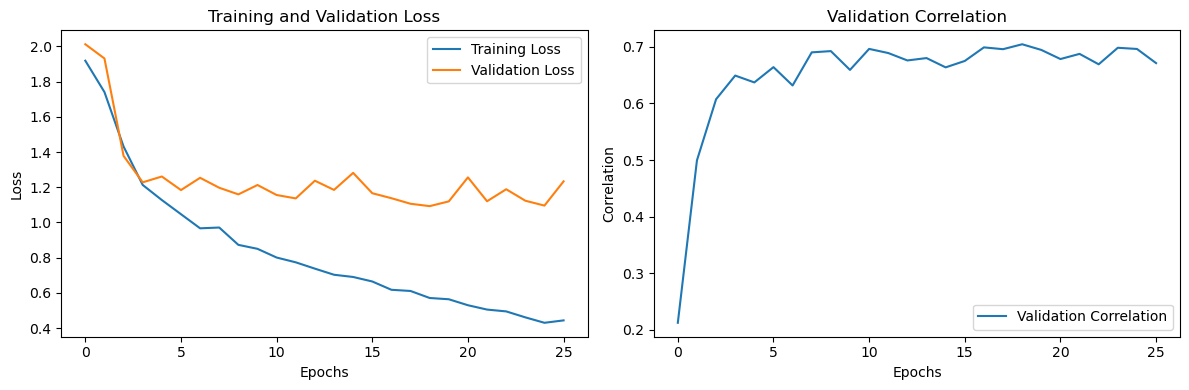

In [38]:
import pickle
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR, CosineAnnealingLR
from sklearn.metrics import accuracy_score, f1_score
import math
import matplotlib.pyplot as plt
from torch.optim.lr_scheduler import ReduceLROnPlateau

class MOSIDataset(Dataset):
    def __init__(self, data_path, split='train'):
        # 从pickle文件加载数据
        with open(data_path, 'rb') as f:
            data = pickle.load(f)
        
        # 选择合适的数据分割
        self.vision = data[split]['vision']
        self.text = data[split]['text']
        self.audio = data[split]['audio']
        self.labels = data[split]['labels']
        self.ids = data[split]['id']

        # 处理音频数据中的异常值
        self.audio[self.audio == float('inf')] = 0.0
        self.audio[self.audio == float('-inf')] = 0.0

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # 提取特征和标签
        vision = torch.tensor(self.vision[idx], dtype=torch.float32)
        text = torch.tensor(self.text[idx], dtype=torch.float32)
        audio = torch.tensor(self.audio[idx], dtype=torch.float32)
        label = torch.tensor(self.labels[idx], dtype=torch.float32).squeeze()

        return vision, text, audio, label

# 位置编码实现
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=50, dropout=0.1):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)
        
        # 创建位置编码矩阵
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        # 计算sin和cos位置编码
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        # 添加batch维度并注册为buffer
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)
        
    def forward(self, x):
        # x shape: [batch_size, seq_len, d_model]
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

# 自注意力模块
class SelfAttention(nn.Module):
    def __init__(self, d_model, nhead, dropout=0.1):
        super(SelfAttention, self).__init__()
        self.multihead_attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=nhead,
            dropout=dropout,
            batch_first=True
        )
        self.norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        attn_output, _ = self.multihead_attn(x, x, x)
        # 残差连接和Layer Normalization
        output = x + self.dropout(attn_output)
        output = self.norm(output)
        return output

# 交叉注意力模块
class CrossModalAttention(nn.Module):
    def __init__(self, d_model, nhead, dropout=0.1):
        super(CrossModalAttention, self).__init__()
        self.multihead_attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=nhead,
            dropout=dropout,
            batch_first=True
        )
        self.norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, query, key_value):
        """
        query: 查询模态的特征 [batch_size, seq_len, d_model]
        key_value: 键/值模态的特征 [batch_size, seq_len, d_model]
        """
        attn_output, attn_weights = self.multihead_attn(
            query=query,
            key=key_value,
            value=key_value
        )
        # 残差连接和Layer Normalization
        output = query + self.dropout(attn_output)
        output = self.norm(output)
        return output, attn_weights

# 前馈网络
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super(FeedForward, self).__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.norm = nn.LayerNorm(d_model)
        
    def forward(self, x):
        # 前馈网络 + 残差连接 + 层归一化
        ff_output = self.linear2(self.dropout(F.gelu(self.linear1(x))))
        output = x + self.dropout(ff_output)
        output = self.norm(output)
        return output

# 门控机制模块
class GatedFusion(nn.Module):
    def __init__(self, d_model, dropout=0.1):
        super(GatedFusion, self).__init__()
        self.gate1 = nn.Linear(d_model * 2, d_model)
        self.gate2 = nn.Linear(d_model * 2, d_model)
        self.gate3 = nn.Linear(d_model * 2, d_model)
        
        # 融合权重计算
        self.fusion_weights = nn.Linear(d_model * 3, 3)
        
        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(d_model)
        
    def forward(self, x1, x2, x3):
        # 两两融合
        g12 = torch.sigmoid(self.gate1(torch.cat([x1, x2], dim=-1)))
        g13 = torch.sigmoid(self.gate2(torch.cat([x1, x3], dim=-1)))
        g23 = torch.sigmoid(self.gate3(torch.cat([x2, x3], dim=-1)))
        
        # 第一级融合
        f12 = g12 * x1 + (1 - g12) * x2
        f13 = g13 * x1 + (1 - g13) * x3
        f23 = g23 * x2 + (1 - g23) * x3
        
        # 计算融合权重
        weights = F.softmax(self.fusion_weights(torch.cat([f12, f13, f23], dim=-1)), dim=-1)
        
        # 加权求和
        w1 = weights[:,:,0].unsqueeze(-1)
        w2 = weights[:,:,1].unsqueeze(-1)
        w3 = weights[:,:,2].unsqueeze(-1)
        
        # 最终融合
        fused = w1 * f12 + w2 * f13 + w3 * f23
        
        # 残差连接和Layer Normalization
        fused = self.norm(fused)
        return fused

# 替换复杂的EnhancedMultimodalTransformer模型为更简洁有效的设计
class ImprovedMultimodalTransformer(nn.Module):
    def __init__(self):
        super(ImprovedMultimodalTransformer, self).__init__()
        
        # 模型参数
        self.d_model = 128
        self.nhead = 4  # 减少注意力头数
        self.num_layers = 2
        self.dropout_rate = 0.1  # 减少dropout
        
        # 数据特征归一化
        self.vision_norm = nn.LayerNorm(35)
        self.text_norm = nn.LayerNorm(300) 
        self.audio_norm = nn.LayerNorm(74)
        
        # 特征投影层
        self.vision_fc = nn.Linear(35, self.d_model)
        self.text_fc = nn.Linear(300, self.d_model)
        self.audio_fc = nn.Linear(74, self.d_model)
        
        # 位置编码
        self.position_enc = PositionalEncoding(
            d_model=self.d_model,
            dropout=self.dropout_rate
        )
        
        # 单模态编码器
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.d_model,
            nhead=self.nhead,
            dim_feedforward=2*self.d_model,  # 减小前馈网络大小
            dropout=self.dropout_rate,
            batch_first=True
        )
        
        # 为每个模态创建Transformer编码器
        self.vision_encoder = nn.TransformerEncoder(encoder_layer, num_layers=self.num_layers)
        self.text_encoder = nn.TransformerEncoder(encoder_layer, num_layers=self.num_layers)
        self.audio_encoder = nn.TransformerEncoder(encoder_layer, num_layers=self.num_layers)
        
        # 简化的注意力融合
        self.cross_attn_t2v = nn.MultiheadAttention(
            embed_dim=self.d_model,
            num_heads=self.nhead,
            dropout=self.dropout_rate,
            batch_first=True
        )
        
        self.cross_attn_t2a = nn.MultiheadAttention(
            embed_dim=self.d_model,
            num_heads=self.nhead,
            dropout=self.dropout_rate,
            batch_first=True
        )
        
        # 融合后的Transformer层
        self.fusion_encoder = nn.TransformerEncoder(encoder_layer, num_layers=1)
        
        # 线性变换和输出层
        self.fc1 = nn.Linear(self.d_model, 64)
        self.fc2 = nn.Linear(64, 1)
        
    def forward(self, vision, text, audio):
        # 数据归一化
        vision = self.vision_norm(vision)
        text = self.text_norm(text)
        audio = self.audio_norm(audio)
        
        # 线性投影
        vision = F.relu(self.vision_fc(vision))
        text = F.relu(self.text_fc(text))
        audio = F.relu(self.audio_fc(audio))
        
        # 添加位置编码
        vision = self.position_enc(vision)
        text = self.position_enc(text)
        audio = self.position_enc(audio)
        
        # 单模态编码
        vision_enc = self.vision_encoder(vision)
        text_enc = self.text_encoder(text)
        audio_enc = self.audio_encoder(audio)
        
        # 以文本为核心的交叉注意力
        # 文本关注视觉
        text_vision_attn, _ = self.cross_attn_t2v(text_enc, vision_enc, vision_enc)
        # 文本关注音频
        text_audio_attn, _ = self.cross_attn_t2a(text_enc, audio_enc, audio_enc)
        
        # 简化的权重融合 (加入残差连接)
        alpha = 0.4  # 文本占比最高
        beta = 0.3   # 视觉权重
        gamma = 0.3  # 音频权重
        
        # 融合特征 (保留原始文本特征的权重更大)
        fused_features = alpha * text_enc + beta * text_vision_attn + gamma * text_audio_attn
        
        # 融合编码
        fusion_out = self.fusion_encoder(fused_features)
        
        # 取序列的最后一个时间步和平均池化结合
        last_hidden = fusion_out[:, -1]
        avg_pool = torch.mean(fusion_out, dim=1)
        final_representation = (last_hidden + avg_pool) / 2
        
        # 输出层
        output = F.relu(self.fc1(final_representation))
        output = self.fc2(output)
        
        # 应用sigmoid将输出约束到(0,1)
        output = torch.sigmoid(output)
        # 缩放到[-3,3]范围
        output = output * 6 - 3
        
        return output

# 修改损失函数调整权重比例
class CombinedLoss(nn.Module):
    def __init__(self, alpha=0.6, beta=0.3, gamma=0.1):
        super(CombinedLoss, self).__init__()
        self.mse_loss = nn.MSELoss()
        self.l1_loss = nn.L1Loss()
        self.smooth_l1 = nn.SmoothL1Loss()
        self.alpha = alpha  # 增加MSE权重
        self.beta = beta    # L1权重
        self.gamma = gamma  # 减少Smooth L1权重
        
    def forward(self, predictions, targets):
        mse = self.mse_loss(predictions, targets)
        l1 = self.l1_loss(predictions, targets)
        smooth_l1 = self.smooth_l1(predictions, targets)
        
        # 组合损失
        combined_loss = self.alpha * mse + self.beta * l1 + self.gamma * smooth_l1
        return combined_loss

def eval_mosi_regression(y_pred, y_true, exclude_zero=False):
    test_preds = y_pred.view(-1).cpu().detach().numpy()
    test_truth = y_true.view(-1).cpu().detach().numpy()

    test_preds_a7 = np.clip(test_preds, a_min=-3., a_max=3.)
    test_truth_a7 = np.clip(test_truth, a_min=-3., a_max=3.)
    test_preds_a5 = np.clip(test_preds, a_min=-2., a_max=2.)
    test_truth_a5 = np.clip(test_truth, a_min=-2., a_max=2.)

    mae = np.mean(np.absolute(test_preds - test_truth))
    corr = np.corrcoef(test_preds, test_truth)[0][1]
    mult_a7 = multiclass_acc(test_preds_a7, test_truth_a7)
    mult_a5 = multiclass_acc(test_preds_a5, test_truth_a5)
    
    non_zeros = np.array([i for i, e in enumerate(test_truth) if e != 0])
    non_zeros_binary_truth = (test_truth[non_zeros] > 0)
    non_zeros_binary_preds = (test_preds[non_zeros] > 0)

    non_zeros_acc2 = accuracy_score(non_zeros_binary_preds, non_zeros_binary_truth)
    non_zeros_f1_score = f1_score(non_zeros_binary_preds, non_zeros_binary_truth, average='weighted')
    
    eval_results = {
        "Non0_acc_2": round(float(non_zeros_acc2), 4),
        "Non0_F1_score": round(float(non_zeros_f1_score), 4),
        "Mult_acc_5": round(float(mult_a5), 4),
        "Mult_acc_7": round(float(mult_a7), 4),
        "MAE": round(float(mae), 4),
        "Corr": round(float(corr), 4)
    }   
    return eval_results

def multiclass_acc(y_pred, y_true):
    y_pred = np.round(y_pred)
    y_true = np.round(y_true)

    # Compute the accuracy
    acc = np.mean(np.equal(y_pred, y_true))
    
    return acc

class EarlyStopping:
    def __init__(self, patience=7, verbose=False, delta=0, path='best_model.pth'):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf
        self.delta = delta
        self.path = path
        
    def __call__(self, val_corr, model):
        # 相关系数越高越好，所以我们取负值进行最小化比较
        score = val_corr
        
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_corr, model)
        elif score <= self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_corr, model)
            self.counter = 0
            
    def save_checkpoint(self, val_corr, model):
        if self.verbose:
            print(f'Validation correlation increased ({self.best_score:.6f} --> {val_corr:.6f}).  Saving model ...')
        torch.save(model.state_dict(), self.path)

def train_model(model, train_loader, valid_loader, criterion, optimizer, scheduler, device, epochs, model_path='best_model_improved.pth', patience=7):
    model.to(device)
    
    # 初始化早停
    early_stopping = EarlyStopping(patience=patience, verbose=True, path=model_path)
    
    # 记录训练过程
    train_losses = []
    valid_losses = []
    valid_corrs = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for i, (vision, text, audio, labels) in enumerate(train_loader):
            vision, text, audio, labels = vision.to(device), text.to(device), audio.to(device), labels.to(device)

            optimizer.zero_grad()

            # 模型前向获得输出
            outputs = model(vision, text, audio)
            # 计算损失
            loss = criterion(outputs.squeeze(), labels.squeeze())
            # 反向传播，计算梯度
            loss.backward()
            
            # 梯度裁剪，防止梯度爆炸
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()

            running_loss += loss.item()
            
        # 每个epoch结束后记录训练损失
        epoch_train_loss = running_loss / len(train_loader)
        train_losses.append(epoch_train_loss)
        
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {epoch_train_loss:.4f}')

        # 验证
        val_loss, val_corr = validate_model(model, valid_loader, criterion, device, return_loss=True)
        valid_losses.append(val_loss)
        valid_corrs.append(val_corr)
        
        # 学习率调整
        if isinstance(scheduler, ReduceLROnPlateau):
            scheduler.step(val_loss)
        else:
            scheduler.step()

        # 早停检查
        early_stopping(val_corr, model)
        if early_stopping.early_stop:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

    # 绘制训练过程图
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Training Loss')
    plt.plot(valid_losses, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training and Validation Loss')
    
    plt.subplot(1, 2, 2)
    plt.plot(valid_corrs, label='Validation Correlation')
    plt.xlabel('Epochs')
    plt.ylabel('Correlation')
    plt.legend()
    plt.title('Validation Correlation')
    
    plt.tight_layout()
    plt.savefig('training_process.png')
    
    print(f"Training complete. Best validation correlation: {early_stopping.best_score:.4f}")
    return early_stopping.best_score

def validate_model(model, valid_loader, criterion, device, return_loss=False):
    model.eval()
    valid_loss = 0.0

    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for vision, text, audio, labels in valid_loader:
            vision, text, audio, labels = vision.to(device), text.to(device), audio.to(device), labels.to(device)

            outputs = model(vision, text, audio)
            loss = criterion(outputs.squeeze(), labels.squeeze())

            valid_loss += loss.item()

            all_preds.append(outputs)
            all_labels.append(labels)

    avg_valid_loss = valid_loss / len(valid_loader)
    print(f'Validation Loss: {avg_valid_loss:.4f}')
    
    all_preds = torch.cat(all_preds, dim=0)
    all_labels = torch.cat(all_labels, dim=0)

    # 计算评价指标
    eval_results = eval_mosi_regression(all_preds, all_labels)
    print(eval_results)

    if return_loss:
        return avg_valid_loss, eval_results["Corr"]
    else:
        return eval_results["Corr"]

def test_model(model, model_path, test_loader, criterion, device):
    # 加载最佳模型
    model.load_state_dict(torch.load(model_path))
    model.to(device)
    
    # 评估测试集
    model.eval()
    test_loss = 0.0
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for vision, text, audio, labels in test_loader:
            vision, text, audio, labels = vision.to(device), text.to(device), audio.to(device), labels.to(device)
            
            outputs = model(vision, text, audio)
            loss = criterion(outputs.squeeze(), labels.squeeze())
            
            test_loss += loss.item()
            
            all_preds.append(outputs)
            all_labels.append(labels)
    
    print(f'Test Loss: {test_loss/len(test_loader):.4f}')
    
    all_preds = torch.cat(all_preds, dim=0)
    all_labels = torch.cat(all_labels, dim=0)
    
    # 计算评价指标
    eval_results = eval_mosi_regression(all_preds, all_labels)
    print("测试集结果:")
    print(eval_results)
    
    return eval_results

def compare_models(original_results, improved_results):
    # 创建对比图
    metrics = ['Non0_acc_2', 'Non0_F1_score', 'Mult_acc_5', 'Mult_acc_7', 'MAE', 'Corr']
    orig_values = [original_results[m] for m in metrics]
    improved_values = [improved_results[m] for m in metrics]
    
    # 对于MAE，值越小越好，所以我们需要将它取负值以便在图表上一致显示（更高=更好）
    orig_values[4] = -orig_values[4]
    improved_values[4] = -improved_values[4]
    
    # 数据准备
    x = np.arange(len(metrics))
    width = 0.35
    
    plt.figure(figsize=(12, 6))
    plt.bar(x - width/2, orig_values, width, label='Original Model')
    plt.bar(x + width/2, improved_values, width, label='Improved Model')
    
    plt.ylabel('Metric Value')
    plt.title('Comparison of Original and Improved Models')
    plt.xticks(x, metrics)
    plt.legend()
    
    # 添加数值标签
    for i, v in enumerate(orig_values):
        if metrics[i] == 'MAE':
            plt.text(i - width/2, v, f"{-original_results['MAE']:.3f}", ha='center', va='bottom')
        else:
            plt.text(i - width/2, v, f"{original_results[metrics[i]]:.3f}", ha='center', va='bottom')
            
    for i, v in enumerate(improved_values):
        if metrics[i] == 'MAE':
            plt.text(i + width/2, v, f"{-improved_results['MAE']:.3f}", ha='center', va='bottom')
        else:
            plt.text(i + width/2, v, f"{improved_results[metrics[i]]:.3f}", ha='center', va='bottom')
    
    plt.tight_layout()
    plt.savefig('model_comparison.png')
    plt.close()
    
    # 打印提升百分比
    print("\n性能提升百分比：")
    for metric in metrics:
        if metric == 'MAE':  # MAE越小越好
            change = (original_results[metric] - improved_results[metric]) / original_results[metric] * 100
            print(f"{metric}: 减少了 {change:.2f}%")
        else:  # 其他指标越大越好
            change = (improved_results[metric] - original_results[metric]) / original_results[metric] * 100
            print(f"{metric}: 提升了 {change:.2f}%")

def main():
    # 固定随机数种子，确保实验结果可重复性
    seed = 42
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    
    device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    print(f"使用设备: {device}")
    
    # 定义参数
    batch_size = 16
    epochs = 30
    learning_rate = 1e-3  # 回到更常规的学习率
    
    # 加载数据
    data_path = './mosi_raw.pkl'
    
    # 创建数据集和数据加载器
    train_dataset = MOSIDataset(data_path, split='train')
    valid_dataset = MOSIDataset(data_path, split='valid')
    test_dataset = MOSIDataset(data_path, split='test')
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    # 使用改进版模型
    model = ImprovedMultimodalTransformer()
    
    # 修改损失函数权重
    criterion = CombinedLoss(alpha=0.6, beta=0.3, gamma=0.1)
    
    # 使用Adam优化器，轻微的权重衰减
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    
    # 使用余弦退火学习率调度
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs*len(train_loader), eta_min=1e-5)
    
    # 训练模型
    print("开始训练改进版多模态Transformer模型...")
    best_val_corr = train_model(
        model=model,
        train_loader=train_loader,
        valid_loader=valid_loader,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        epochs=epochs,
        model_path='best_model_improved.pth',
        patience=7  # 增加耐心值
    )
    
    # 测试改进版模型
    print("\n===== 改进版模型测试结果 =====")
    improved_results = test_model(model, 'best_model_improved.pth', test_loader, criterion, device)
    
    # 原始模型结果数据
    original_results = {
        "Non0_acc_2": 0.7393,
        "Non0_F1_score": 0.7403,
        "Mult_acc_5": 0.3382,
        "Mult_acc_7": 0.2974,
        "MAE": 1.0871,
        "Corr": 0.5513
    }
    
    # 可视化结果对比
    compare_models(original_results, improved_results)
    
if __name__ == "__main__":
    main()